# Plot Dataset

In [1]:
import obspy, io, subprocess, utils, os, logging, re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import obspy.core.utcdatetime as utc
from obspy.clients.fdsn import Client
from eqcct.stream import st_predictor

2026-02-16 19:04:12.104948: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-02-16 19:04:12.104979: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


Visualise the downloaded waveforms against its manual pick (true label)

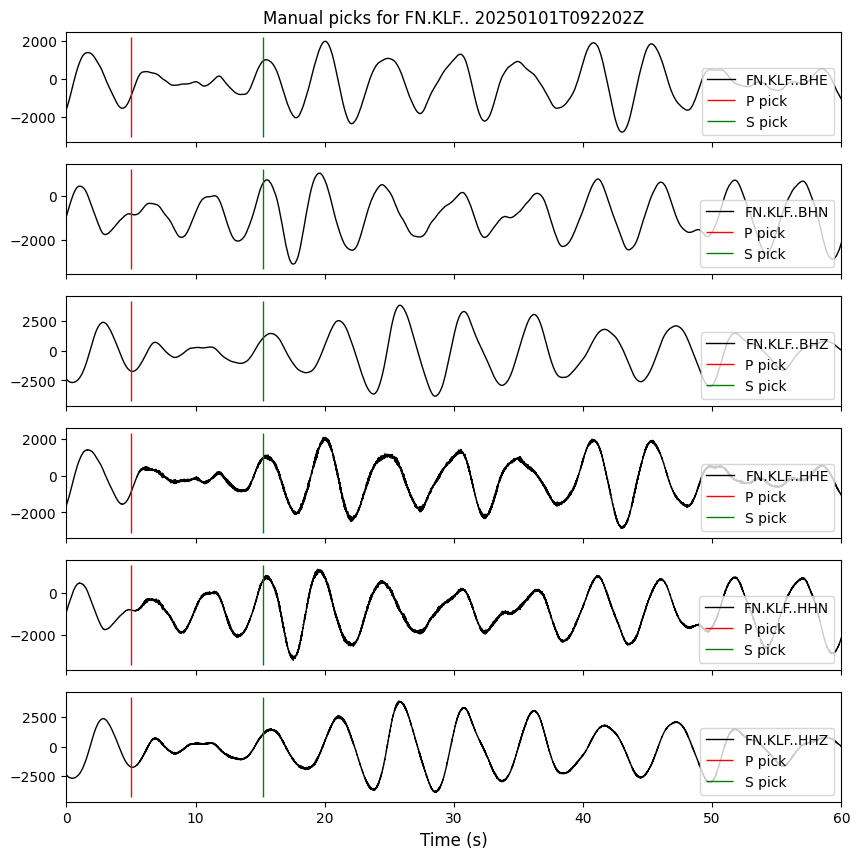

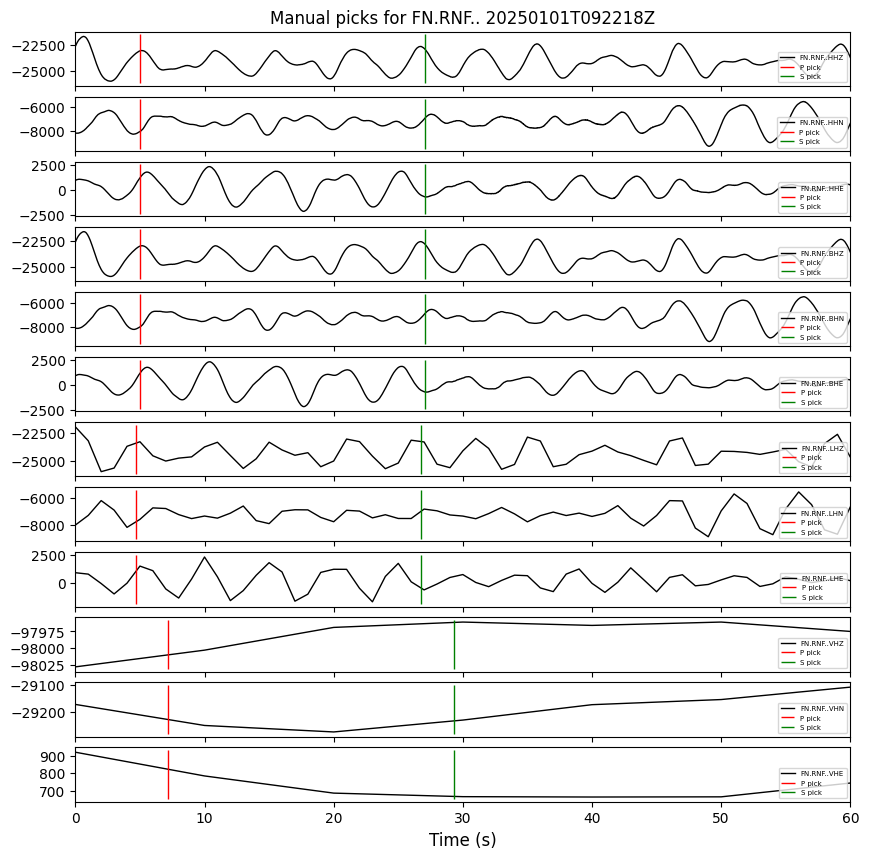

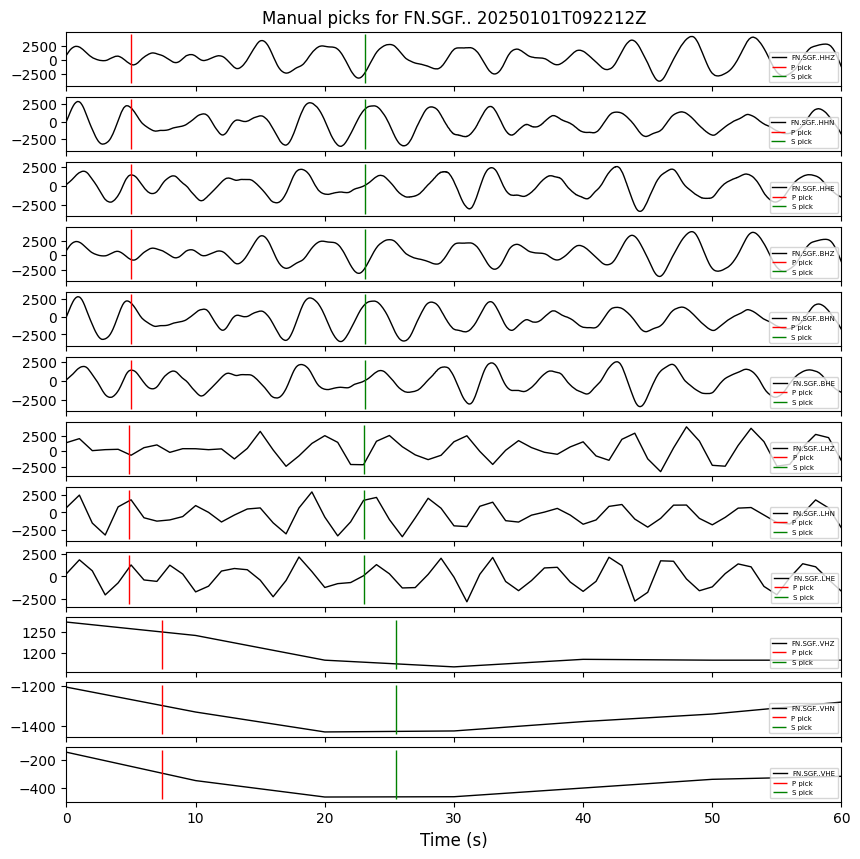

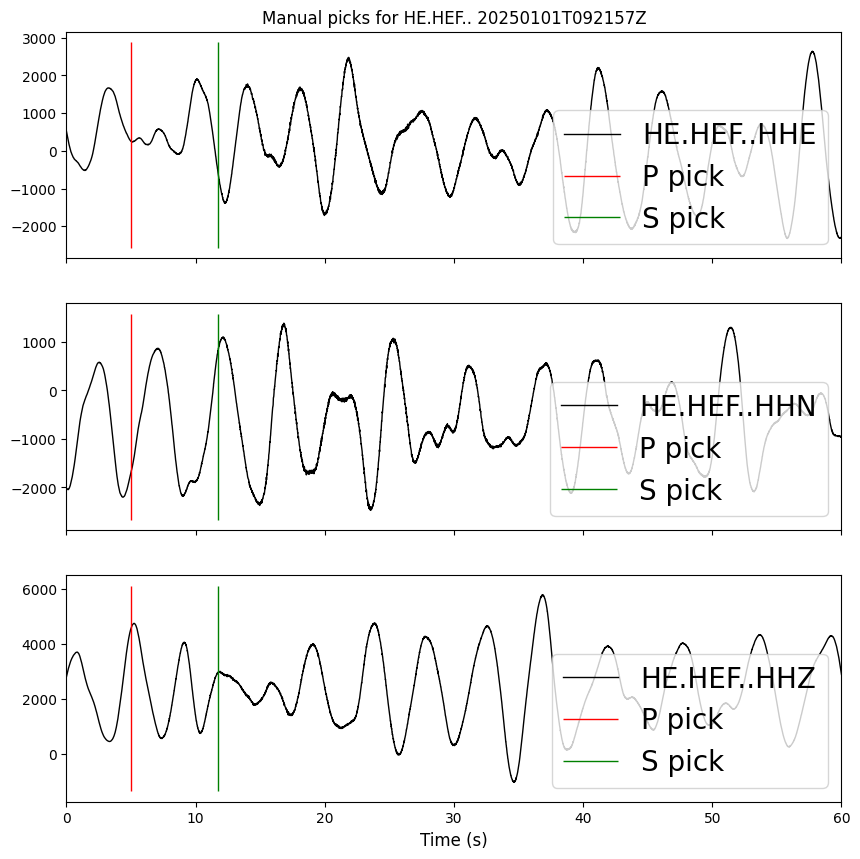

No waveform data for NO.ARA0.. 20250101T092242Z
No waveform data for UP.ERTU.. 20250101T092213Z
No waveform data for UP.ERTU.. 20250101T092213Z
No waveform data for UP.LANU.. 20250101T092156Z
No waveform data for UP.PAJU.. 20250101T092205Z


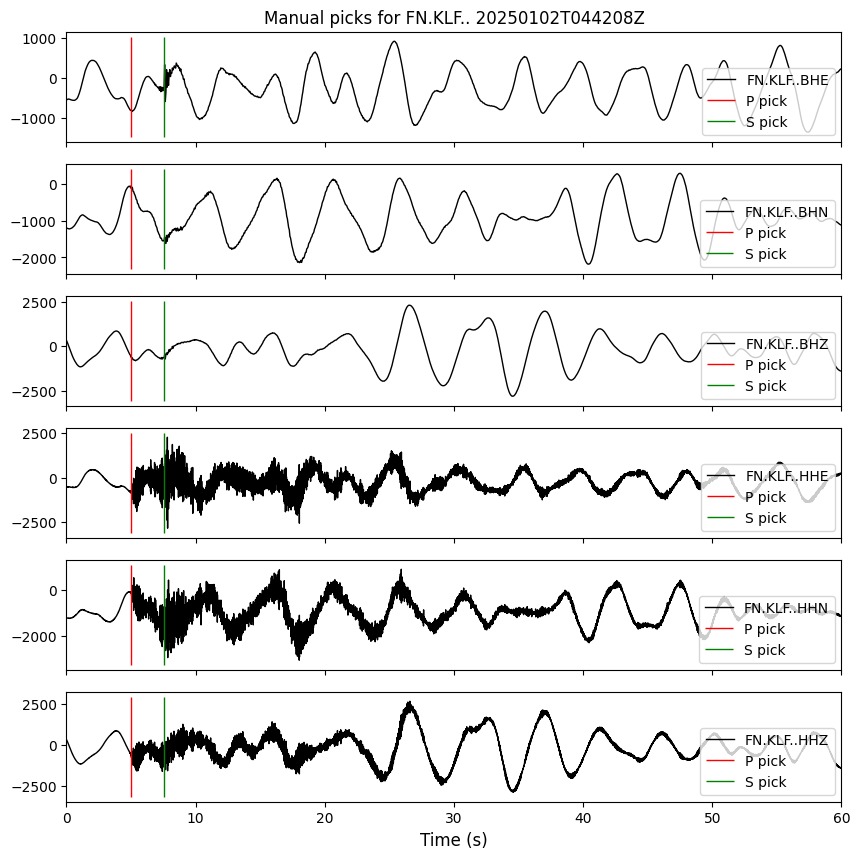

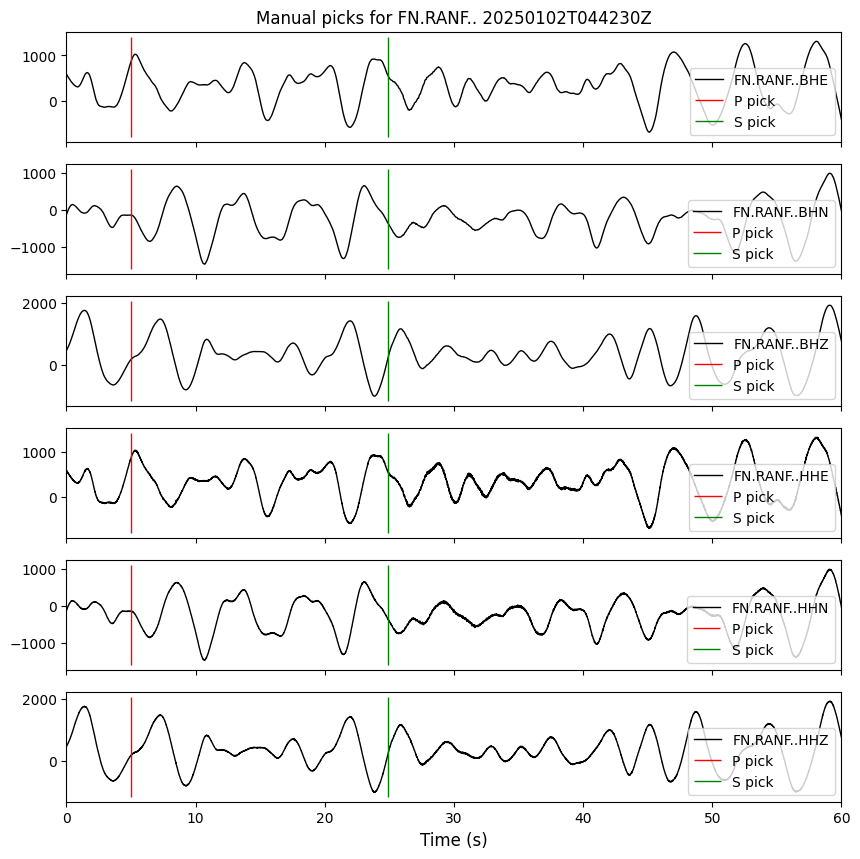

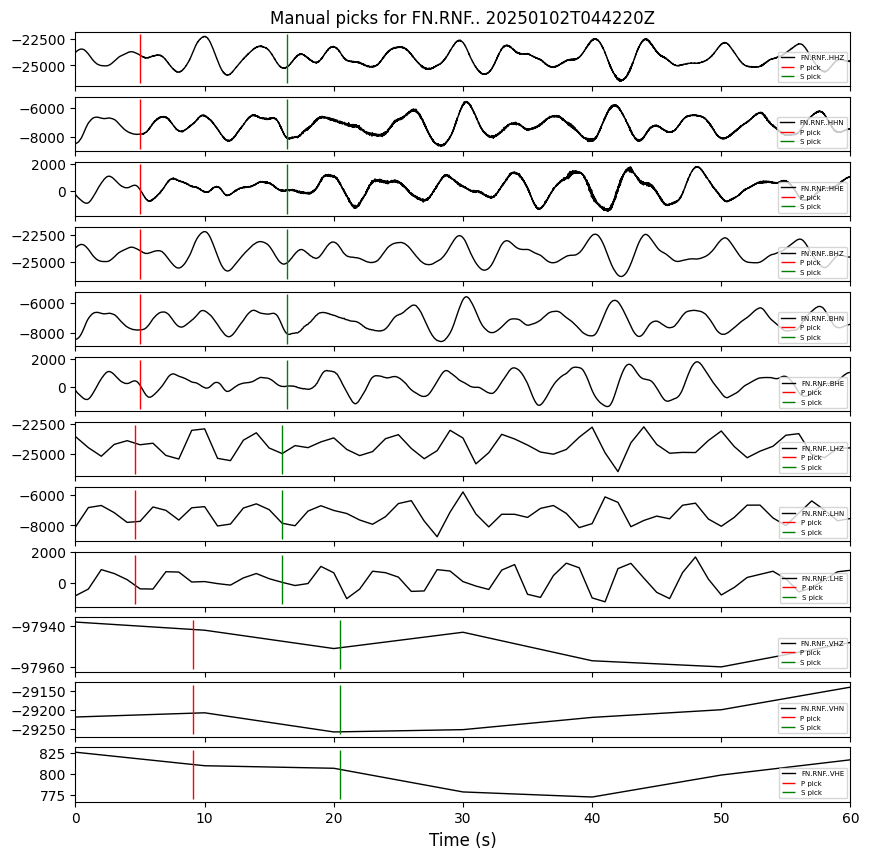

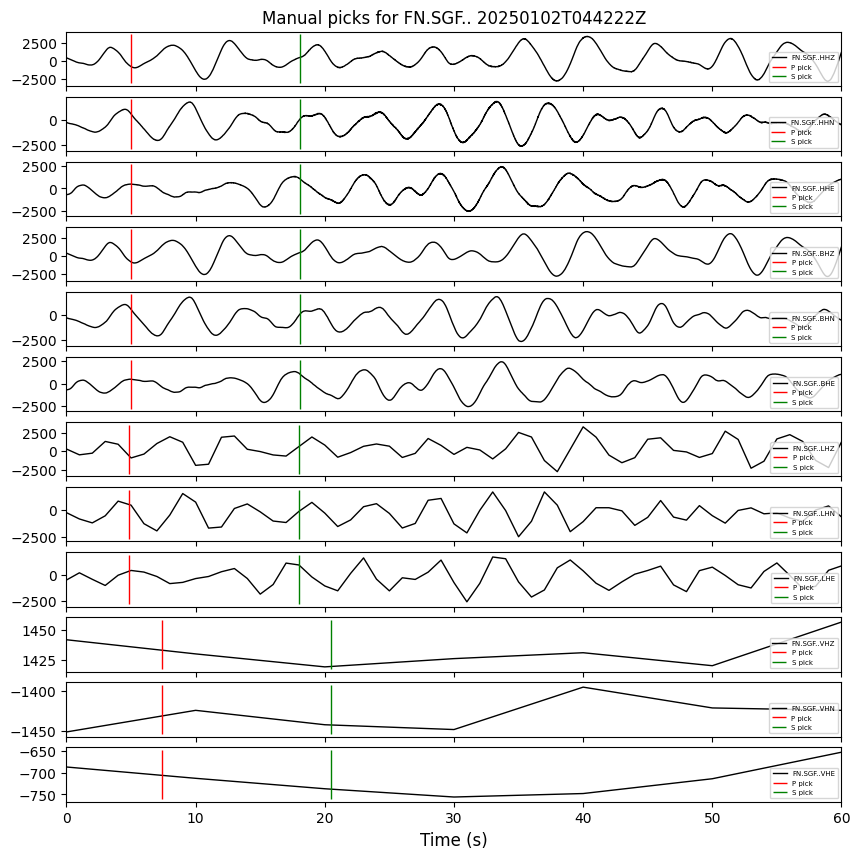

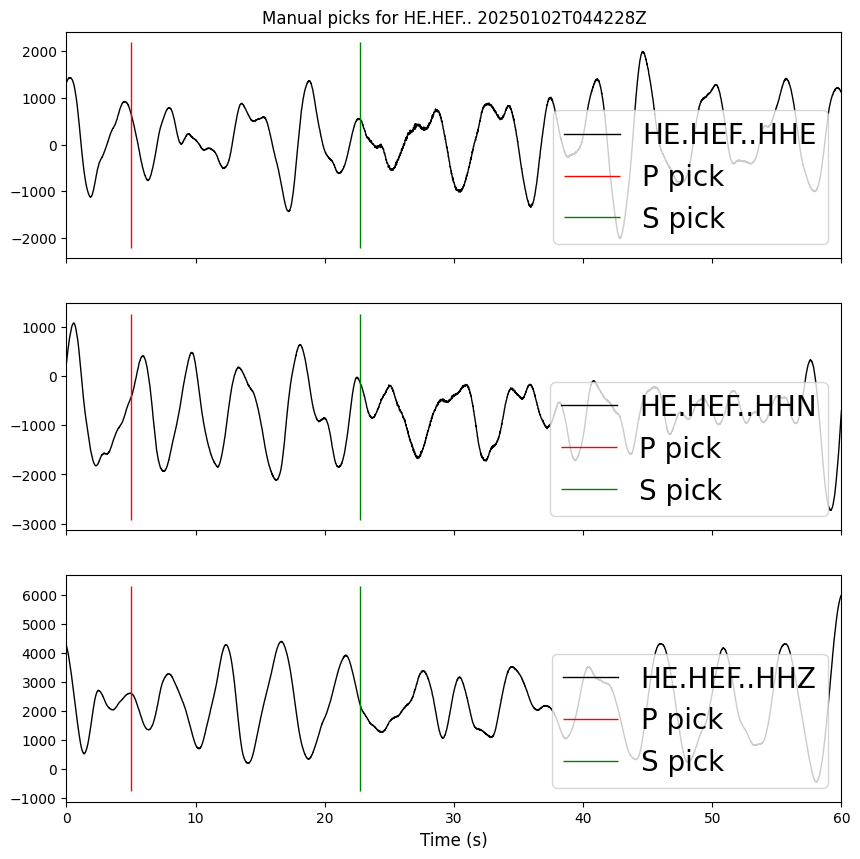

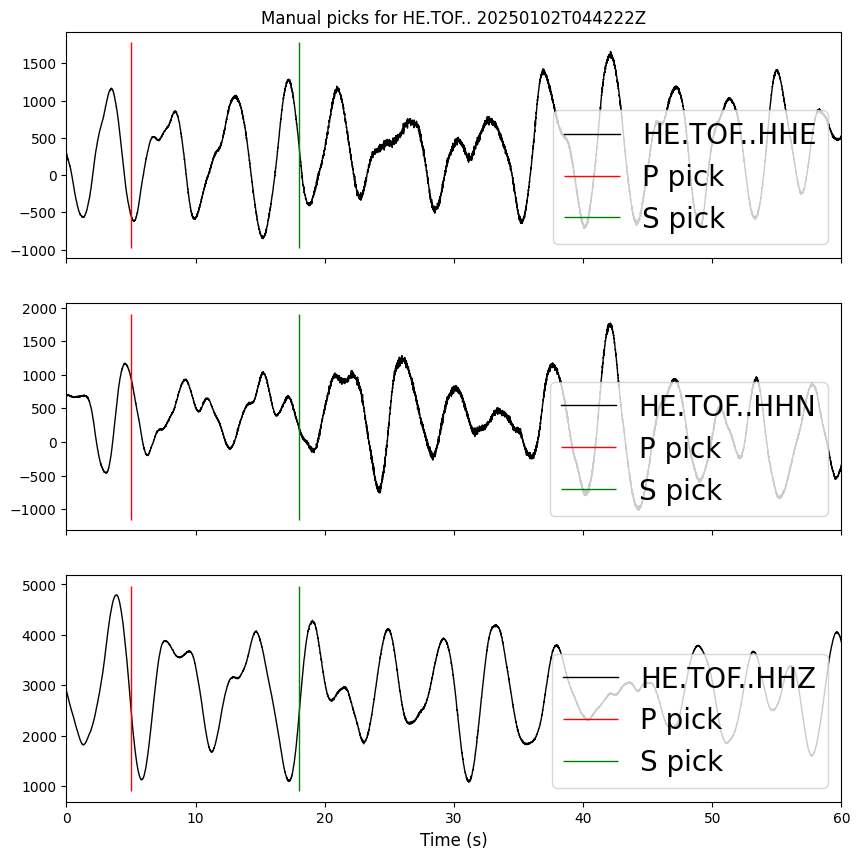

In [4]:
df_labels = pd.read_csv(utils.FILENAME_Y)

counter = 0

for id, p_time, s_time in zip(df_labels["file_name"], df_labels["p_arrival_time"], df_labels["s_arrival_time"]):
    match = re.split(r" [|-] ", id)
    seed_string = match[0]
    win_start = obspy.UTCDateTime(match[1]).strftime("%Y%m%dT%H%M%SZ")
    win_end = obspy.UTCDateTime(match[2]).strftime("%Y%m%dT%H%M%SZ")

    network_code = seed_string.split(".")[0]
    station_code = seed_string.split(".")[1]
    p_time = obspy.UTCDateTime(p_time) if not pd.isnull(p_time) else None
    s_time = obspy.UTCDateTime(s_time) if not pd.isnull(s_time) else None

    dir_name = Path(utils.WAVEFORM_DIR) / f'{win_start}_{win_end}' / station_code
    if os.path.isdir(dir_name):
        st = obspy.Stream()
        for filename in os.listdir(dir_name):
            st += obspy.read(dir_name / filename)

        utils.plot_traces(st,
                    ptime=p_time,
                    stime=s_time,
                    title=f"Manual picks for {network_code}.{station_code}.. {win_start}",
                    showf=True
                    )
    else:
        print(f"No waveform data for {network_code}.{station_code}.. {win_start}")

       
    counter += 1

    if counter == 15:
        break

Visualise prediction against true labels 

In [ ]:
import obspy.core.utcdatetime as utc
from obspy.clients.fdsn import Client
from eqcct.stream import st_predictor
from eqcct import plot_traces
import pandas as pd
import os

os.system('rm -rf ./detections')

cl=Client(utils.ISUH_IP_ADDR)
start = utc.UTCDateTime(2025, 1, 7, 4, 14, 14, 00000)
print(start)
st = cl.get_waveforms('HE', 'OUF', '*', '*', start, start+60)

st_predictor(input_modelP='eqcct/eqcctone/ModelPS/test_trainer_024.h5',
     input_modelS='eqcct/eqcctone/ModelPS/test_trainer_021.h5',
     stinput = st,
     output_dir='detections',
     P_threshold=0.01,
     S_threshold=0.01, 
     number_of_plots=10,
     normalization_mode='std',
     batch_size=1,
     overlap=0.8,
     gpuid=None,
     gpu_limit=None) 

data = pd.read_csv('detections/OUF_outputs/X_prediction_results.csv', low_memory=False)

data

02-16 18:40 [INFO] [EQCCT_Picker] Running EQCCT_Picker


02-16 18:40 [INFO] [EQCCT_Picker] *** Loading the model ...


2025-01-07T04:14:14.000000Z


02-16 18:40 [INFO] [EQCCT_Picker] *** Loading is complete!


/home/ad/lxhome/n/ngdeqi/Linux/Documents/DATA11004 Project/eqdet/detections False




02-16 18:40 [INFO] [EQCCT_Picker] Finished the prediction in: 0 hours and 0 minutes and 2.85 seconds.
02-16 18:40 [INFO] [EQCCT_Picker] *** Detected: 1 events.
02-16 18:40 [INFO] [EQCCT_Picker]  *** Wrote the results into --> " /home/ad/lxhome/n/ngdeqi/Linux/Documents/DATA11004 Project/eqdet/detections/OUF_outputs "


,file_name,network,station,instrument_type,station_lat,station_lon,station_elv,p_arrival_time,p_probability,s_arrival_time,s_probability
0,HE.OUF..HHZ | 2025-01-07T04:14:14.000000Z - 20...,0,OUF,0,0,0,0,2025-01-07 04:14:19.410000,0.869,2025-01-07 04:14:21.670000,0.876


TODO:
* Demo prediction, plotting label and prediction in the same graph
* Helper function to extract mseed waveform based on window time and seed string